# Advertising click logs at their own width

Criteo's click logs record one advertising impression per row: whether it
was clicked, thirteen integer counts, and twenty-six categorical fields
whose values are hashed. Nobody outside Criteo knows what the fields
mean. What everybody in the field knows is what the data costs to model:
the categorical values number in the millions, and every published method
on this data begins by throwing most of them away.

This notebook does not throw them away. It has three parts.

1. **What is in this data.** The row, the vocabulary, the fields, the
   stream. Five minutes to know a dataset you have never seen.
2. **The experiment.** One hypothesis, one encoding, one index, and a
   measurement of whether the index can be trusted. Then the map, drawn
   once per neighbour count, so you can watch structure appear.
3. **What we found.** How many populations there are, whether the
   clustering agrees with the map, what distinguishes each region,
   whether the regions click differently, and what it all cost.

Every number here was measured on the machine named in the last cell.
Nothing is quoted from a paper.

What you need: the UltraDim wheel, `pyarrow`, `pandas`, `matplotlib`,
`pillow`, a GPU for the maps and the clustering, and an internet
connection for a 97 MB download on the first run.

Data: Criteo 1TB Click Logs, Criteo AI Lab, licensed CC BY-NC-SA 4.0,
https://huggingface.co/datasets/criteo/CriteoClickLogs. One shard of the
first day is downloaded and read from its head. No data is redistributed.

## The control block

Every size lives here. As shipped, the whole notebook runs in about eight
minutes on an Apple M3 Max, which is enough to see every figure. The
sizes for a full study are beside each.

In [1]:
ROWS_INGEST    = 50_000      # impressions ingested and indexed          (study: 1_000_000)
ROWS_MAP       = 3_000       # impressions drawn on the maps             (study: 10_000)
ROWS_PILOT     = 20_000      # impressions used to choose index settings (study: 50_000)
K_MAX          = 6           # maps drawn at k = 1, 2 ... K_MAX          (study: 20)
N_QUERIES      = 200         # held-out queries scored against exact answers (study: 1_000)
CLUSTER_COUNTS = [3, 4, 6, 8, 12]        # clusterings compared on their quality score
TUNE_SETTINGS  = [(2048, 4), (512, 4)]   # (projection width, seeds); study adds 1024 and 8 seeds

PROJECTION_DIM = 2048        # the general default, and this study's setting
SEEDS          = 4
ACTIVE_SWEEP   = [2, 4]      # seeds used per query, measured against the oracle

DATA_DIR = "data_criteo"     # the shard; ignored by git
DB_DIR   = "criteo_db"       # the database; ignored by git
FIG_DIR  = "figures_criteo"  # the figures; ignored by git
SHARD    = "part-00015-99c339d5-fbac-4110-9dcf-75453a61a5c1.c000.snappy.parquet"
SHARD_URL = ("https://huggingface.co/datasets/criteo/CriteoClickLogs/resolve/main/"
             "data/day%3D2015-02-15/" + SHARD)

### The look

One palette, one serif for titles, one monospace for hashes. Every figure
carries its finding in the title, not a description of its axes.

In [2]:
import json
import math
import os
import platform
import subprocess
import time
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import ultradim

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter
from PIL import Image

INK   = "#16202e"   # near-black: all type and rules
GREY  = "#a8b0bb"   # the corpus
CLICK = "#1f7a4d"   # a click means go
WARM  = "#b4573a"   # the one accent, for the thing being pointed at
BAND  = ["#16202e", "#3d5a73", "#6f8fa3", "#b4573a", "#d99b6c", "#7d8c5c",
         "#a4696f", "#4f6d5a", "#8a7fa3", "#c2a55c", "#5b7d8f", "#9a6b4f"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 170, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "serif", "font.serif": ["Iowan Old Style", "Georgia", "Palatino"],
    "font.size": 10.5, "axes.titlesize": 13, "axes.labelsize": 10,
    "axes.titlelocation": "left", "axes.titlepad": 14, "axes.labelpad": 7,
    "axes.edgecolor": INK, "axes.linewidth": 0.8, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False, "legend.fontsize": 9,
})
MONO = {"family": "monospace"}
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)


def in_notebook():
    try:
        from IPython import get_ipython
        return type(get_ipython()).__name__ == "ZMQInteractiveShell"
    except ImportError:
        return False


IN_NOTEBOOK = in_notebook()
if IN_NOTEBOOK:
    from IPython.display import Image as NBImage, display


def finish(fig, name, source):
    """Close a figure with its source line, save it, and show it in a notebook."""
    fig.text(0.005, 0.005, source, fontsize=8.5, color=GREY, ha="left")
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path)
    plt.close(fig)
    if IN_NOTEBOOK:
        display(NBImage(filename=path))
    else:
        print("figure:", path)


COST = []


def cost(step, measure, value):
    COST.append((step, measure, value))
    print(f"  {step}: {measure} = {value}")


db = ultradim.UltraDim(DB_DIR)


def rpc(rpc_name, **fields):
    out = json.loads(db.call_json(rpc_name, json.dumps(fields)))
    if isinstance(out, dict) and out.get("error_message"):
        raise RuntimeError(f"{rpc_name}: {out['error_message']}")
    return out


print("wheel", ultradim.__version__, "| notebook", IN_NOTEBOOK)

wheel 0.4.0 | notebook True


# Part one: what is in this data

## The shard, and one impression

One shard of the first day: 97 MB, 1,529,035 impressions in the order
Criteo served them. Here is the first one, exactly as it arrives.

In [3]:
shard_path = os.path.join(DATA_DIR, SHARD)
if not os.path.exists(shard_path):
    t0 = time.time()
    urllib.request.urlretrieve(SHARD_URL, shard_path)
    print(f"downloaded {os.path.getsize(shard_path) // 2**20} MB in {time.time() - t0:.0f} s")

INT = [f"integer_feature_{i}" for i in range(1, 14)]
CAT = [f"categorical_feature_{i}" for i in range(1, 27)]

table = pq.read_table(shard_path).to_pandas()
row0 = table.iloc[0]
print(f"shard: {len(table):,} impressions, {len(table.columns)} columns, "
      f"click rate {table['label'].mean():.2%}\n")
print("impression 0, as it arrives")
print("  clicked :", int(row0["label"]))
print("  integers:", ", ".join(
    f"I{i+1}={'-' if pd.isna(row0[c]) else int(row0[c])}" for i, c in enumerate(INT[:6])), "…")
print("  hashes  :", ", ".join(
    f"C{i+1}={row0[c] or '-'}" for i, c in enumerate(CAT[:4])), "…")

shard: 1,529,035 impressions, 40 columns, click rate 3.21%

impression 0, as it arrives
  clicked : 0
  integers: I1=-, I2=84, I3=-, I4=31, I5=12, I6=0 …
  hashes  : C1=8a2b1e43, C2=68fe2a00, C3=f9b6c7f8, C4=9d24e8e8 …


## The vocabulary

Every categorical value is one column of the true design matrix, and each
integer field becomes a handful of columns once bucketed. So the first
question is how many columns that is, and how often each one is used.

The answer decides the whole notebook. If most values are rare, then the
usual preparation, which replaces every value seen fewer than ten times
with one shared token, destroys most of the vocabulary before modelling
begins.

In [4]:
def bucket(x):
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return "missing"
    x = int(x)
    return str(int(math.floor(math.log2(x)))) if x > 2 else "1"


def features(df):
    """One impression becomes 39 tokens: 26 categorical, 13 bucketed integers."""
    ints = df[INT].to_numpy(dtype=object)
    cats = df[CAT].to_numpy(dtype=object)
    out = []
    for r in range(len(df)):
        f = [f"I{i + 1}={bucket(ints[r, i])}" for i in range(13)]
        f += [f"C{i + 1}={cats[r, i] if cats[r, i] is not None else 'missing'}" for i in range(26)]
        out.append(f)
    return out


f0 = features(table.iloc[:1])[0]
print("impression 0, as 39 tokens")
print("  " + "   ".join(f0[:4]))
print("  " + "   ".join(f0[13:16]), "  …")

t0 = time.time()
feats_all, marks = [], []
for start in range(0, len(table), 50_000):
    feats_all.extend(features(table.iloc[start:start + 50_000]))
    marks.append(len(feats_all))
cast_s = time.time() - t0

seen, growth_pairs = set(), []
mark_set = set(marks)
for i, f in enumerate(feats_all, 1):
    seen.update(f)
    if i in mark_set:
        growth_pairs.append((i, len(seen)))
counts = Counter(t for f in feats_all for t in f)

cost("cast, whole shard", "impressions per second", f"{len(table) / cast_s:,.0f}")
cost("vocabulary, whole shard", "distinct features", f"{len(counts):,}")

rare = sum(1 for c in counts.values() if c < 10)
share_rare = rare / len(counts)
share_occurrences = sum(c for c in counts.values() if c < 10) / sum(counts.values())
print(f"\n{rare:,} of {len(counts):,} features ({share_rare:.1%}) appear fewer than ten times")
print(f"together they account for {share_occurrences:.1%} of all feature occurrences")

impression 0, as 39 tokens
  I1=missing   I2=6   I3=missing   I4=4
  C1=8a2b1e43   C2=68fe2a00   C3=f9b6c7f8   …
  cast, whole shard: impressions per second = 91,693
  vocabulary, whole shard: distinct features = 1,697,282

1,591,840 of 1,697,282 features (93.8%) appear fewer than ten times
together they account for 3.9% of all feature occurrences


The figure below is the argument for this notebook. Rank the features by
how often they appear, and plot frequency against rank: the line is
straight over five decades, the signature every catalogue, vocabulary and
audience shares. The shaded region is everything the standard preparation
discards.

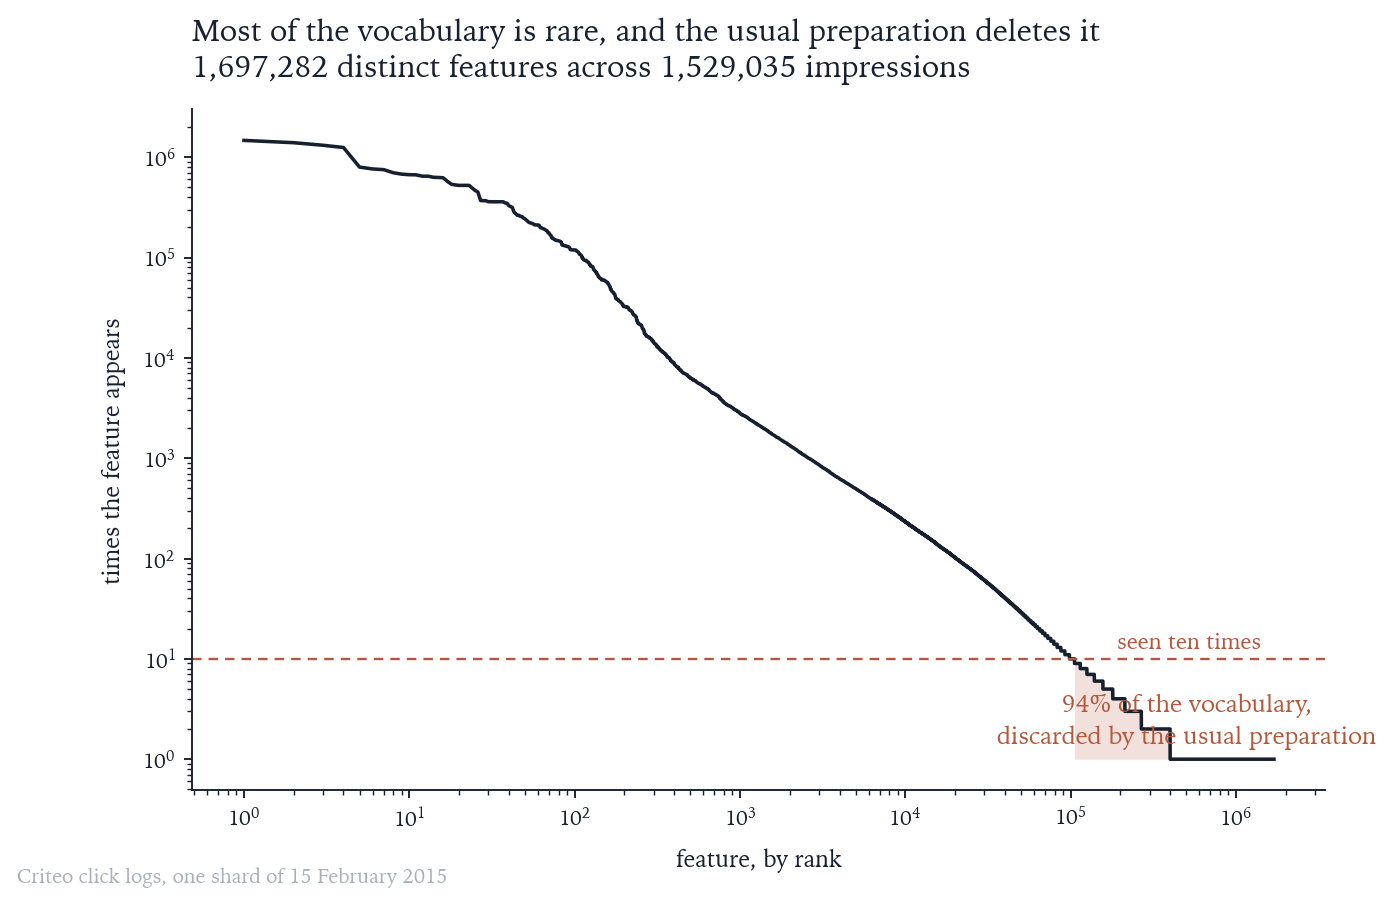

In [5]:
freqs = np.sort(np.fromiter(counts.values(), dtype=np.int64))[::-1]
ranks = np.arange(1, len(freqs) + 1)
cut = int(np.searchsorted(-freqs, -10, side="right"))

fig, ax = plt.subplots(figsize=(8.6, 5.2))
ax.loglog(ranks, freqs, color=INK, linewidth=1.5)
ax.fill_between(ranks[cut:], 1, freqs[cut:], color=WARM, alpha=0.18, linewidth=0)
ax.axhline(10, color=WARM, linewidth=1.0, linestyle=(0, (4, 3)))
ax.text(ranks[-1], 11, "seen ten times  ", color=WARM, fontsize=9.5, ha="right", va="bottom")
ax.text(ranks[cut + (len(freqs) - cut) // 4], 2.4,
        f"{share_rare:.0%} of the vocabulary,\ndiscarded by the usual preparation",
        color=WARM, fontsize=10.5, ha="center", va="center", linespacing=1.4)
ax.set_xlabel("feature, by rank")
ax.set_ylabel("times the feature appears")
ax.set_title("Most of the vocabulary is rare, and the usual preparation deletes it\n"
             f"{len(counts):,} distinct features across {len(feats_all):,} impressions")
finish(fig, "01_vocabulary.png", "Criteo click logs, one shard of 15 February 2015")

## The fields

Thirty-nine fields, and they are nothing like each other. A few
categorical fields hold hundreds of thousands of distinct values each;
the thirteen integer fields hold a dozen buckets apiece. Area is the
share of the vocabulary a field owns; the darker a field, the more often
it arrives empty.

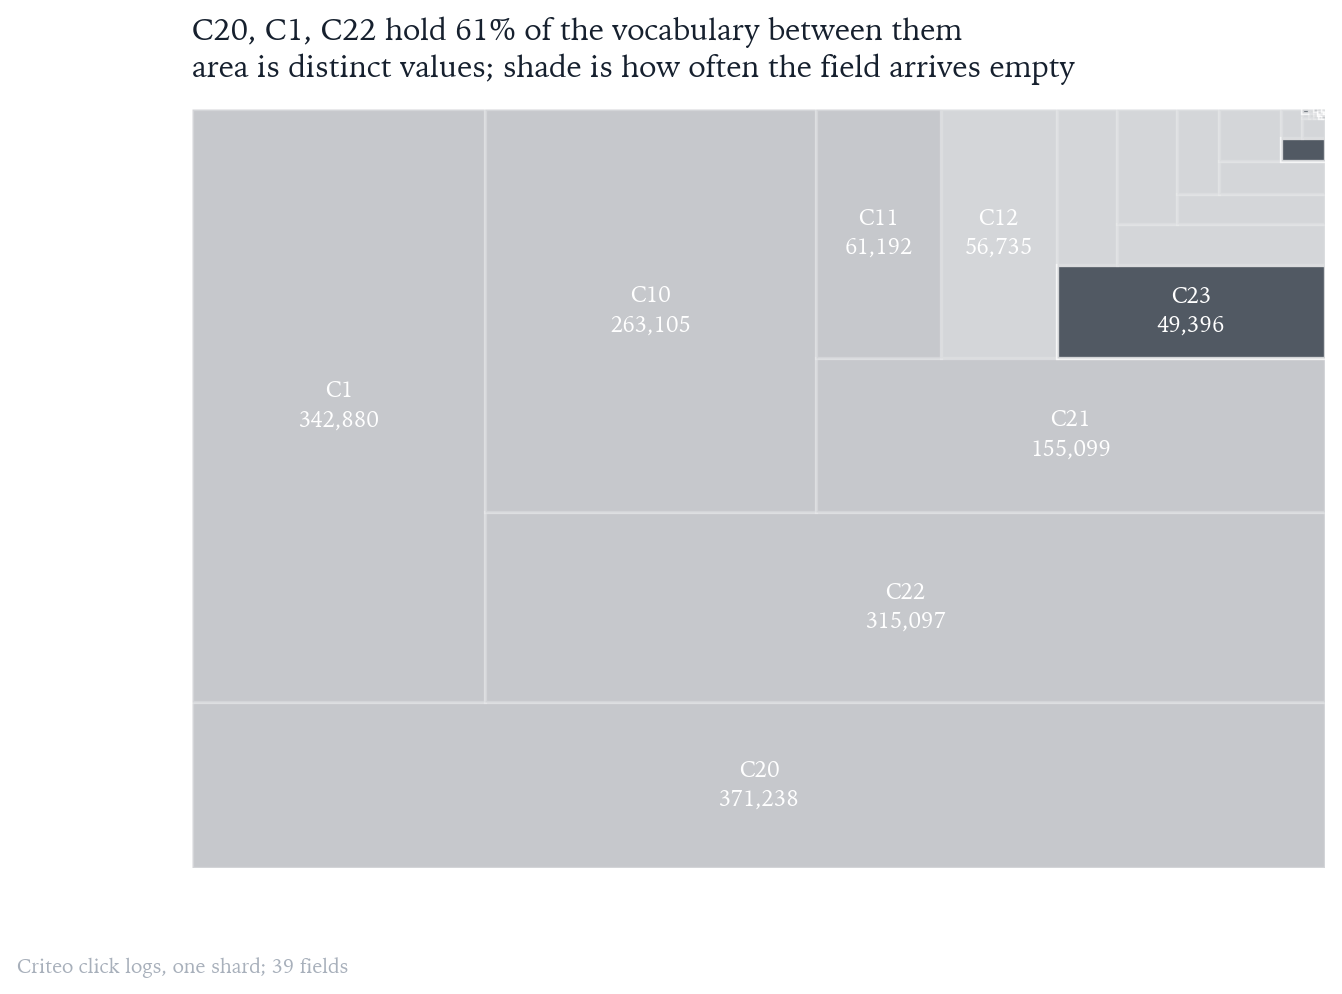

In [6]:
per_field, miss_field = Counter(), Counter()
for tok, c in counts.items():
    field = tok.split("=", 1)[0]
    per_field[field] += 1
    if tok.endswith("=missing"):
        miss_field[field] = c
fields = [f"C{i}" for i in range(1, 27)] + [f"I{i}" for i in range(1, 14)]
sizes = np.array([per_field.get(f, 0) for f in fields], dtype=float)
missr = np.array([miss_field.get(f, 0) / len(feats_all) for f in fields])
order = np.argsort(-sizes)


def slice_and_dice(values, x, y, w, h):
    """A treemap in twenty lines: enough for 39 rectangles, and no dependency."""
    out = []
    vals = values / values.sum()
    i, horizontal = 0, w > h
    while i < len(vals):
        take, acc = i, 0.0
        target = max(vals[i], vals[i:].sum() / max(1.0, (len(vals) - i) ** 0.5))
        while take < len(vals) and acc < target:
            acc += vals[take]
            take += 1
        frac = acc / max(vals[i:].sum(), 1e-12)
        if horizontal:
            bw, oy = w * frac, y
            for v in vals[i:take]:
                bh = h * v / acc
                out.append((x, oy, bw, bh))
                oy += bh
            x += bw
            w -= bw
        else:
            bh, ox = h * frac, x
            for v in vals[i:take]:
                bw = w * v / acc
                out.append((ox, y, bw, bh))
                ox += bw
            y += bh
            h -= bh
        i, horizontal = take, w > h
    return out


fig, ax = plt.subplots(figsize=(8.6, 5.8))
for (rx, ry, rw, rh), idx in zip(slice_and_dice(sizes[order], 0, 0, 1.0, 1.0), order):
    shade = 0.18 + 0.70 * (missr[idx] / max(missr.max(), 1e-9))
    ax.add_patch(Rectangle((rx, ry), rw, rh, facecolor=INK, alpha=shade,
                           edgecolor="white", linewidth=1.4))
    if rw * rh > 0.013:
        ax.text(rx + rw / 2, ry + rh / 2, f"{fields[idx]}\n{int(sizes[idx]):,}",
                ha="center", va="center", color="white", fontsize=9.5, linespacing=1.4)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
top3 = ", ".join(fields[i] for i in order[:3])
top3_share = sizes[order[:3]].sum() / sizes.sum()
ax.set_title(f"{top3} hold {top3_share:.0%} of the vocabulary between them\n"
             "area is distinct values; shade is how often the field arrives empty")
finish(fig, "02_fields.png", "Criteo click logs, one shard; 39 fields")

## The stream

The impressions are in the order they were served, so two things are
worth seeing before any modelling: whether the click rate holds through
the file, and how fast new features keep arriving. The second is why a
fixed vocabulary is the wrong idea for this data.

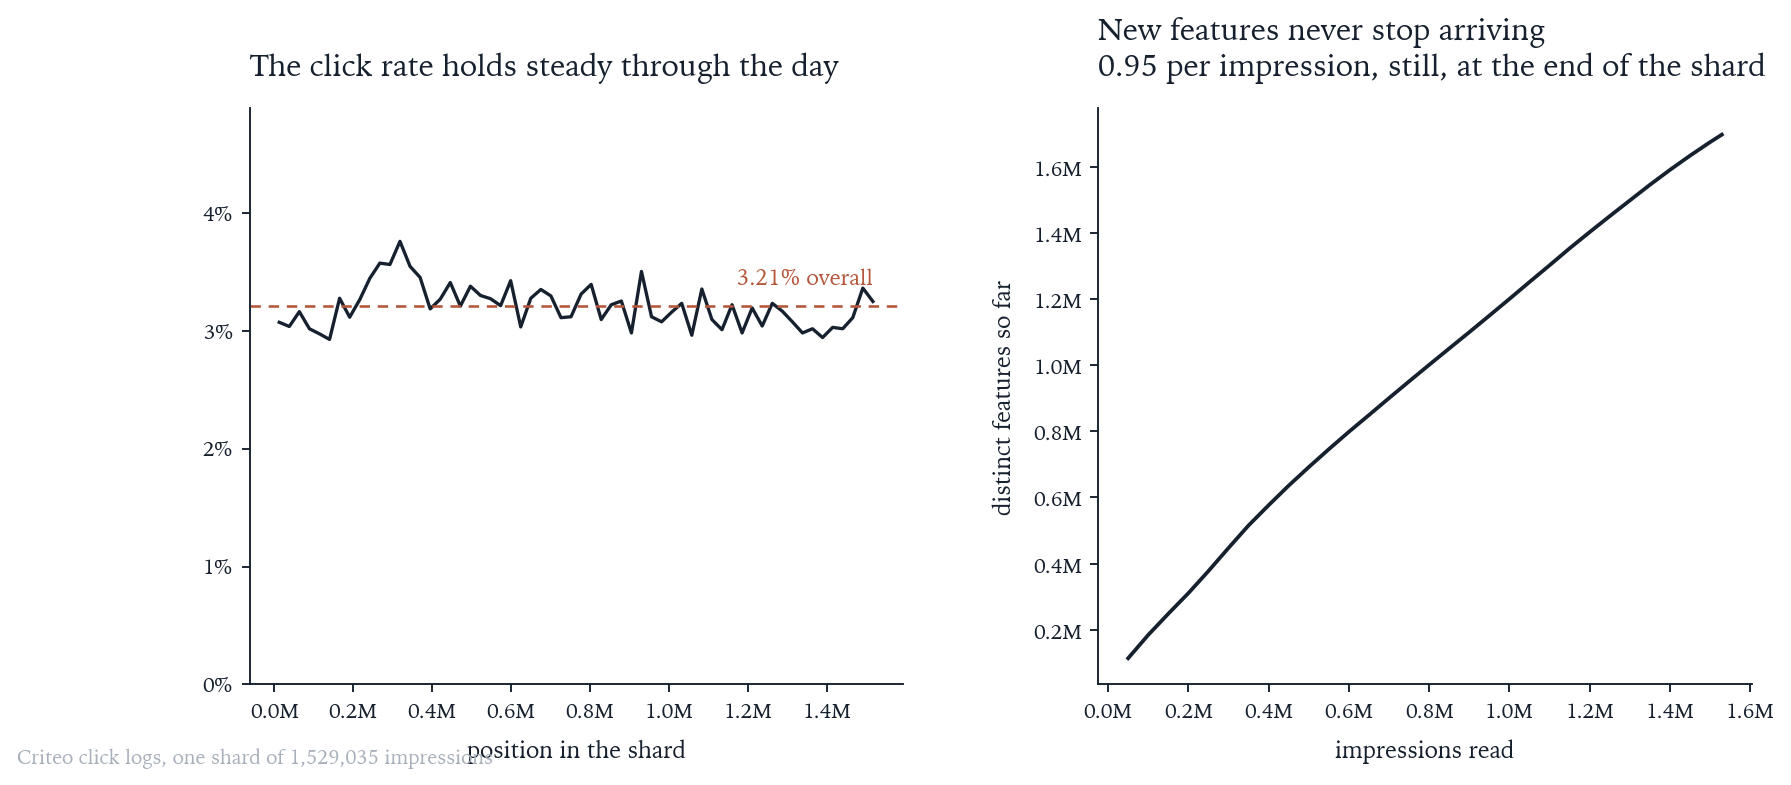

In [7]:
labels_all = table["label"].to_numpy().astype(int)
chunks = np.array_split(np.arange(len(labels_all)), 60)
rate = np.array([labels_all[c].mean() for c in chunks])
mid = np.array([c.mean() for c in chunks])
gx, gy = map(np.array, zip(*growth_pairs))
per_row = (gy[-1] - gy[len(gy) // 2]) / (gx[-1] - gx[len(gx) // 2])

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.4), gridspec_kw={"wspace": 0.30})
ax = axes[0]
ax.plot(mid, rate, color=INK, linewidth=1.4)
ax.axhline(labels_all.mean(), color=WARM, linewidth=1.1, linestyle=(0, (4, 3)))
ax.text(mid[-1], labels_all.mean() * 1.06, f"{labels_all.mean():.2%} overall",
        color=WARM, fontsize=9.5, ha="right")
ax.set_ylim(0, rate.max() * 1.3)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1e6:.1f}M"))
ax.set_xlabel("position in the shard")
ax.set_title("The click rate holds steady through the day")
ax = axes[1]
ax.plot(gx, gy, color=INK, linewidth=1.6)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1e6:.1f}M"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1e6:.1f}M"))
ax.set_xlabel("impressions read")
ax.set_ylabel("distinct features so far")
ax.set_title(f"New features never stop arriving\n{per_row:.2f} per impression, still, "
             "at the end of the shard")
finish(fig, "03_stream.png", "Criteo click logs, one shard of 1,529,035 impressions")

# Part two: the experiment

## The hypothesis

> Two impressions that share features are neighbours in the space of all
> features. If that holds, a map of the impressions at their own width
> will show separated populations rather than a cloud; a clustering run
> at full width will find those same populations without being shown the
> map; and the populations will differ in click rate.

The test is direct: encode every impression without discarding a value,
confirm the index returns the true neighbours, and look.

**The encoding.** Each token is one dimension. An impression carries 39
of them, each holding 1/√39, so every impression is a unit vector and the
cosine between two impressions is the fraction of their 39 features they
share. Two impressions sharing 27 features score 0.69; two sharing none
score 0. Nothing is weighted and nothing is learned. The only lossy step
is bucketing the integer fields, which is the one preparation this
notebook shares with the published methods.

In [8]:
NNZ, VALUE = 39, 1.0 / math.sqrt(39)


class Registry:
    """Every distinct token gets one dimension, in order of first appearance."""

    def __init__(self):
        self.col = {}

    def add(self, toks):
        for t in toks:
            if t not in self.col:
                self.col[t] = len(self.col)

    def __len__(self):
        return len(self.col)


def sparse_row(toks, reg):
    return {"indices": sorted(reg.col[t] for t in toks), "values": [VALUE] * len(toks)}


reg = Registry()
for f in feats_all[:ROWS_INGEST]:
    reg.add(f)
WIDTH = len(reg)
labels = labels_all[:ROWS_INGEST]
shared01 = len(set(feats_all[0]) & set(feats_all[1]))
print(f"{ROWS_INGEST:,} impressions occupy {WIDTH:,} dimensions; click rate {labels.mean():.2%}")
print(f"impressions 0 and 1 share {shared01} of 39 features, so their cosine is {shared01 / 39:.3f}")

50,000 impressions occupy 113,799 dimensions; click rate 3.05%
impressions 0 and 1 share 10 of 39 features, so their cosine is 0.256


## Choosing the index settings by measurement

The index has two settings that matter: the width it projects to, and the
number of seeds. The general default is 2048 with four seeds. Rather than
assert it, the cell below builds a family at each candidate setting over a
pilot of the data and measures recall at 10 against exact brute-force
answers, with the disk each setting costs.

   2048 × 4 seeds: build  21.1 s,  33.8 KB per impression, recall@10 at 2 seeds 0.9805, recall@10 at 4 seeds 0.9960
    512 × 4 seeds: build   6.1 s,   9.2 KB per impression, recall@10 at 2 seeds 0.9630, recall@10 at 4 seeds 0.9955


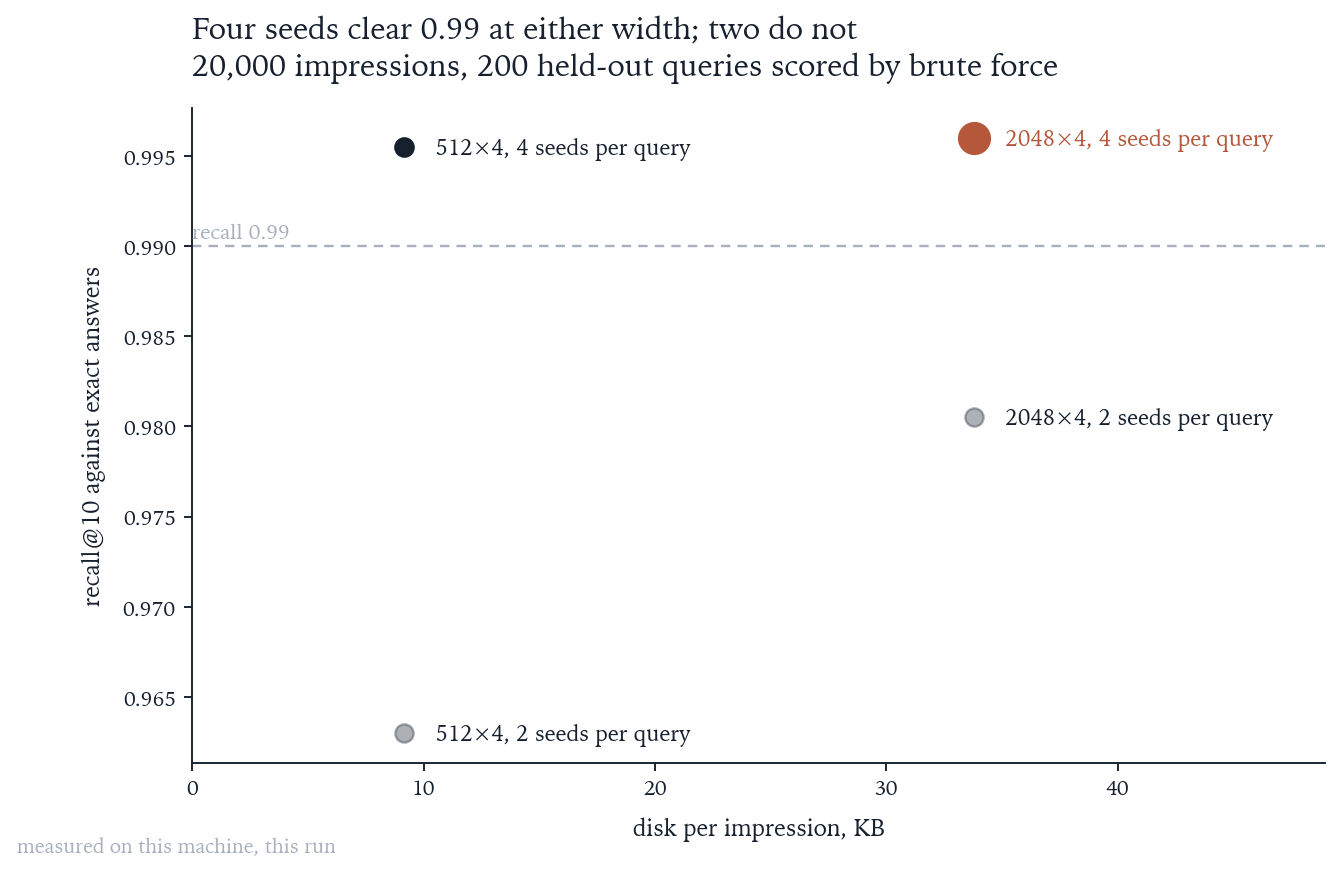

In [9]:
def measure_family(name, rows, width, proj, n_seeds, n_queries=200):
    pool = [101, 202, 303, 404, 505, 606, 707, 808]
    seeds = pool[:n_seeds]
    try:
        rpc("DropUltradimV23Collection", name=name)
    except RuntimeError:
        pass
    rpc("CreateUltradimV23Collection", name=name, source_dim=width, projection_dim=proj,
        seeds=seeds, sparse_substrate=True, max_nnz_per_row=NNZ)
    t0 = time.time()
    for s in range(0, len(rows), 1000):
        b = rows[s:s + 1000]
        rpc("UpsertUltradimV23Points", name=name,
            batch={"row_ids": list(range(s, s + len(b))), "sparse_vectors": b})
    upsert = len(rows) / (time.time() - t0)
    t0 = time.time()
    rpc("BuildUltradimV23TrellisIndex", name=name)
    build = time.time() - t0
    size = sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(DB_DIR)
               for f in fs if name in r)
    oracle = rpc("CreateSparseOracles", name=name, query_ids=list(range(n_queries)), top_k=10)
    rec = {}
    for n_active in ACTIVE_SWEEP:
        if n_active > n_seeds:
            continue
        m = rpc("MeasureRecall", name=name, oracle_path=oracle["artifact_path"], k=10,
                exclude_self=True, use_template=True, active_seeds=seeds[:n_active])
        rec[n_active] = (m["recall_at_k"], m["p50_ms"])
    rpc("DropUltradimV23Collection", name=name)
    return {"proj": proj, "seeds": n_seeds, "upsert": upsert, "build": build,
            "kb": size / len(rows) / 1024, "rec": rec}


reg_pilot = Registry()
for f in feats_all[:ROWS_PILOT]:
    reg_pilot.add(f)
rows_pilot = [sparse_row(f, reg_pilot) for f in feats_all[:ROWS_PILOT]]
tuning = []
for proj, ns in TUNE_SETTINGS:
    r = measure_family(f"tune_{proj}x{ns}", rows_pilot, len(reg_pilot), proj, ns)
    tuning.append(r)
    print(f"  {proj:>5} × {ns} seeds: build {r['build']:5.1f} s, {r['kb']:5.1f} KB per impression, "
          + ", ".join(f"recall@10 at {k} seeds {v[0]:.4f}" for k, v in sorted(r["rec"].items())))

fig, ax = plt.subplots(figsize=(8.6, 5.0))
for r in tuning:
    for n_active, (rc, _p50) in r["rec"].items():
        chosen = (r["proj"], r["seeds"], n_active) == (PROJECTION_DIM, SEEDS, max(ACTIVE_SWEEP))
        ax.scatter(r["kb"], rc, s=170 if chosen else 60, zorder=3,
                   color=WARM if chosen else INK, alpha=1.0 if n_active >= 4 else 0.35)
        ax.annotate(f"  {r['proj']}×{r['seeds']}, {n_active} seeds per query", (r["kb"], rc),
                    xytext=(8, -3), textcoords="offset points", fontsize=9.5,
                    color=WARM if chosen else INK)
ax.axhline(0.99, color=GREY, linewidth=1.0, linestyle=(0, (4, 3)))
ax.set_xlim(0, max(r["kb"] for r in tuning) * 1.45)
ax.text(ax.get_xlim()[0], 0.9902, "recall 0.99", color=GREY, fontsize=9, va="bottom")
ax.set_xlabel("disk per impression, KB")
ax.set_ylabel("recall@10 against exact answers")
ax.set_title("Four seeds clear 0.99 at either width; two do not\n"
             f"{ROWS_PILOT:,} impressions, 200 held-out queries scored by brute force")
finish(fig, "04_settings.png", "measured on this machine, this run")

## Ingest, index, and the recall certificate

The slice goes in at the chosen setting, and the index is graded against
exact brute-force answers for held-out impressions it has never been
queried with. This is the number that decides whether anything downstream
can be believed.

In [10]:
FAM = "criteo"
try:
    have = rpc("GetUltradimV23CollectionInfo", name=FAM)["shards"][0].get("points_count")
except RuntimeError:
    have = None
seeds = [101, 202, 303, 404, 505, 606, 707, 808][:SEEDS]
if have != ROWS_INGEST:
    if have is not None:
        rpc("DropUltradimV23Collection", name=FAM)
    rpc("CreateUltradimV23Collection", name=FAM, source_dim=WIDTH,
        projection_dim=PROJECTION_DIM, seeds=seeds, sparse_substrate=True, max_nnz_per_row=NNZ)
    t0 = time.time()
    for s in range(0, ROWS_INGEST, 1000):
        ids = list(range(s, min(s + 1000, ROWS_INGEST)))
        rpc("UpsertUltradimV23Points", name=FAM, batch={
            "row_ids": ids,
            "sparse_vectors": [sparse_row(feats_all[i], reg) for i in ids],
            "facets": [{"fields": {"click": {"kind": {"IntValue": int(labels[i])}}}} for i in ids]})
    cost("ingest", "impressions per second", f"{ROWS_INGEST / (time.time() - t0):,.0f}")
    t0 = time.time()
    rpc("BuildUltradimV23TrellisIndex", name=FAM)
    cost("index build", "seconds", f"{time.time() - t0:.0f}")
size = sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(DB_DIR)
           for f in fs if FAM in r)
cost("index", "KB per impression", f"{size / ROWS_INGEST / 1024:.1f}")
cost("index", "dimensions", f"{WIDTH:,}")

qids = list(range(ROWS_INGEST - N_QUERIES, ROWS_INGEST))
oracle = rpc("CreateSparseOracles", name=FAM, query_ids=qids, top_k=10)
for n_active in ACTIVE_SWEEP:
    m = rpc("MeasureRecall", name=FAM, oracle_path=oracle["artifact_path"], k=10,
            exclude_self=True, use_template=True, active_seeds=seeds[:n_active])
    cost("search", f"recall@10 at {n_active} seeds", f"{m['recall_at_k']:.4f}")
    cost("search", f"p50 / p95 ms at {n_active} seeds", f"{m['p50_ms']:.2f} / {m['p95_ms']:.2f}")

q = qids[0]
found = rpc("UltradimV23TrellisTemplateSearch", name=FAM,
            sparse_query=sparse_row(feats_all[q], reg), top_k=5, exclude_ids=[q])
print(f"\nimpression {q} (clicked {labels[q]}) and its nearest neighbours")
for r in found["result"]:
    rid = r["id"]["point_id_options"]["Num"]
    shared = len(set(feats_all[q]) & set(feats_all[rid]))
    print(f"  {rid:>6}   cosine {r['score']:.3f}   shares {shared:2d} of 39 features   "
          f"clicked {labels[rid]}")

  index: KB per impression = 35.9
  index: dimensions = 113,799
  search: recall@10 at 2 seeds = 0.9820
  search: p50 / p95 ms at 2 seeds = 2.09 / 2.85
  search: recall@10 at 4 seeds = 0.9950
  search: p50 / p95 ms at 4 seeds = 2.65 / 3.37

impression 49800 (clicked 0) and its nearest neighbours
   16845   cosine 0.795   shares 31 of 39 features   clicked 0
   36677   cosine 0.769   shares 30 of 39 features   clicked 0
   32441   cosine 0.744   shares 29 of 39 features   clicked 0
    5979   cosine 0.718   shares 28 of 39 features   clicked 0
    7218   cosine 0.718   shares 28 of 39 features   clicked 0


## The map, drawn once per neighbour count

A UMAP map is fitted on a neighbour graph, and that graph has one
setting: k, the number of neighbours each impression keeps. It decides
what the map can show, so rather than pick one, this notebook draws the
map at every k from 1 to `K_MAX` and lets you watch.

The impressions to be mapped get a family of their own. A graph built
over a subset of a larger family walks the whole family and keeps only
the candidates that fall inside the subset, which costs recall; giving
the sample its own family avoids that, and is what you would do with a
sample of your own data.

Each frame is aligned to the one before it by the rotation and
translation that best match the impressions they share, so the film does
not spin and the eye can follow one region across frames.

In [11]:
FAM_MAP = "criteo_map"
try:
    have = rpc("GetUltradimV23CollectionInfo", name=FAM_MAP)["shards"][0].get("points_count")
except RuntimeError:
    have = None
if have != ROWS_MAP:
    if have is not None:
        rpc("DropUltradimV23Collection", name=FAM_MAP)
    rpc("CreateUltradimV23Collection", name=FAM_MAP, source_dim=WIDTH,
        projection_dim=PROJECTION_DIM, seeds=seeds, sparse_substrate=True, max_nnz_per_row=NNZ)
    for s in range(0, ROWS_MAP, 1000):
        ids = list(range(s, min(s + 1000, ROWS_MAP)))
        rpc("UpsertUltradimV23Points", name=FAM_MAP, batch={
            "row_ids": ids,
            "sparse_vectors": [sparse_row(feats_all[i], reg) for i in ids],
            "facets": [{"fields": {"click": {"kind": {"IntValue": int(labels[i])}}}} for i in ids]})
    rpc("BuildUltradimV23TrellisIndex", name=FAM_MAP)
WIDTH_MAP = len({t for f in feats_all[:ROWS_MAP] for t in f})
map_ids = list(range(ROWS_MAP))
print(f"{ROWS_MAP:,} impressions to map, {WIDTH_MAP:,} dimensions among them")


def fetch_layout(uid):
    pos, off = {}, 0
    while True:
        page = rpc("GetUltradimV23UmapEmbedding", name=FAM_MAP, umap_id=uid,
                   limit=8192, offset_ordinal=off)
        emb, nc = page["embeddings"], page["n_components"]
        if not emb:
            break
        for i in range(0, len(emb), nc):
            pos[off + i // nc] = (emb[i], emb[i + 1])
        nxt = page.get("next_offset_ordinal")
        if nxt is None or nxt <= off:
            break
        off = nxt
    return pos


def align(prev, cur):
    keys = [k for k in cur if k in prev]
    if len(keys) < 8:
        return cur
    a = np.array([prev[k] for k in keys])
    b = np.array([cur[k] for k in keys])
    am, bm = a.mean(0), b.mean(0)
    u, _, vt = np.linalg.svd((b - bm).T @ (a - am))
    d = np.sign(np.linalg.det(u @ vt)) or 1.0
    r = u @ np.diag([1.0, d]) @ vt
    return {k: tuple((np.array(v) - bm) @ r + am) for k, v in cur.items()}


graphs, layouts, prev = {}, {}, None
for k in range(1, K_MAX + 1):
    t0 = time.time()
    g = rpc("BuildUltradimV23KnnGraph", name=FAM_MAP, k=k, oracle_sample=500)
    gs = time.time() - t0
    graphs[k] = g
    fit = rpc("FitUltradimV23Umap", name=FAM_MAP, graph_id=g["graph_id"], n_components=2,
              n_neighbors=k, deterministic=True, umap_seed=174, force=True)
    raw = fetch_layout(fit["umap_id"])
    layouts[k] = align(prev, raw) if prev is not None else raw
    prev = layouts[k]
    cost(f"map k={k}", "graph recall / seconds", f"{g['measured_recall_at_k']:.4f} / {gs:.0f}")

3,000 impressions to map, 15,159 dimensions among them
  map k=1: graph recall / seconds = 0.9979 / 0
  map k=2: graph recall / seconds = 0.9957 / 0
  map k=3: graph recall / seconds = 0.9964 / 0
  map k=4: graph recall / seconds = 0.9968 / 0
  map k=5: graph recall / seconds = 0.9970 / 0
  map k=6: graph recall / seconds = 0.9975 / 0


At k = 1 every impression is joined to its single nearest neighbour and
nothing else: pairs, and no structure. Each extra neighbour is one more
edge per impression, and the populations pull together. Watch where the
green goes.

6 frames, a GIF and a strip written


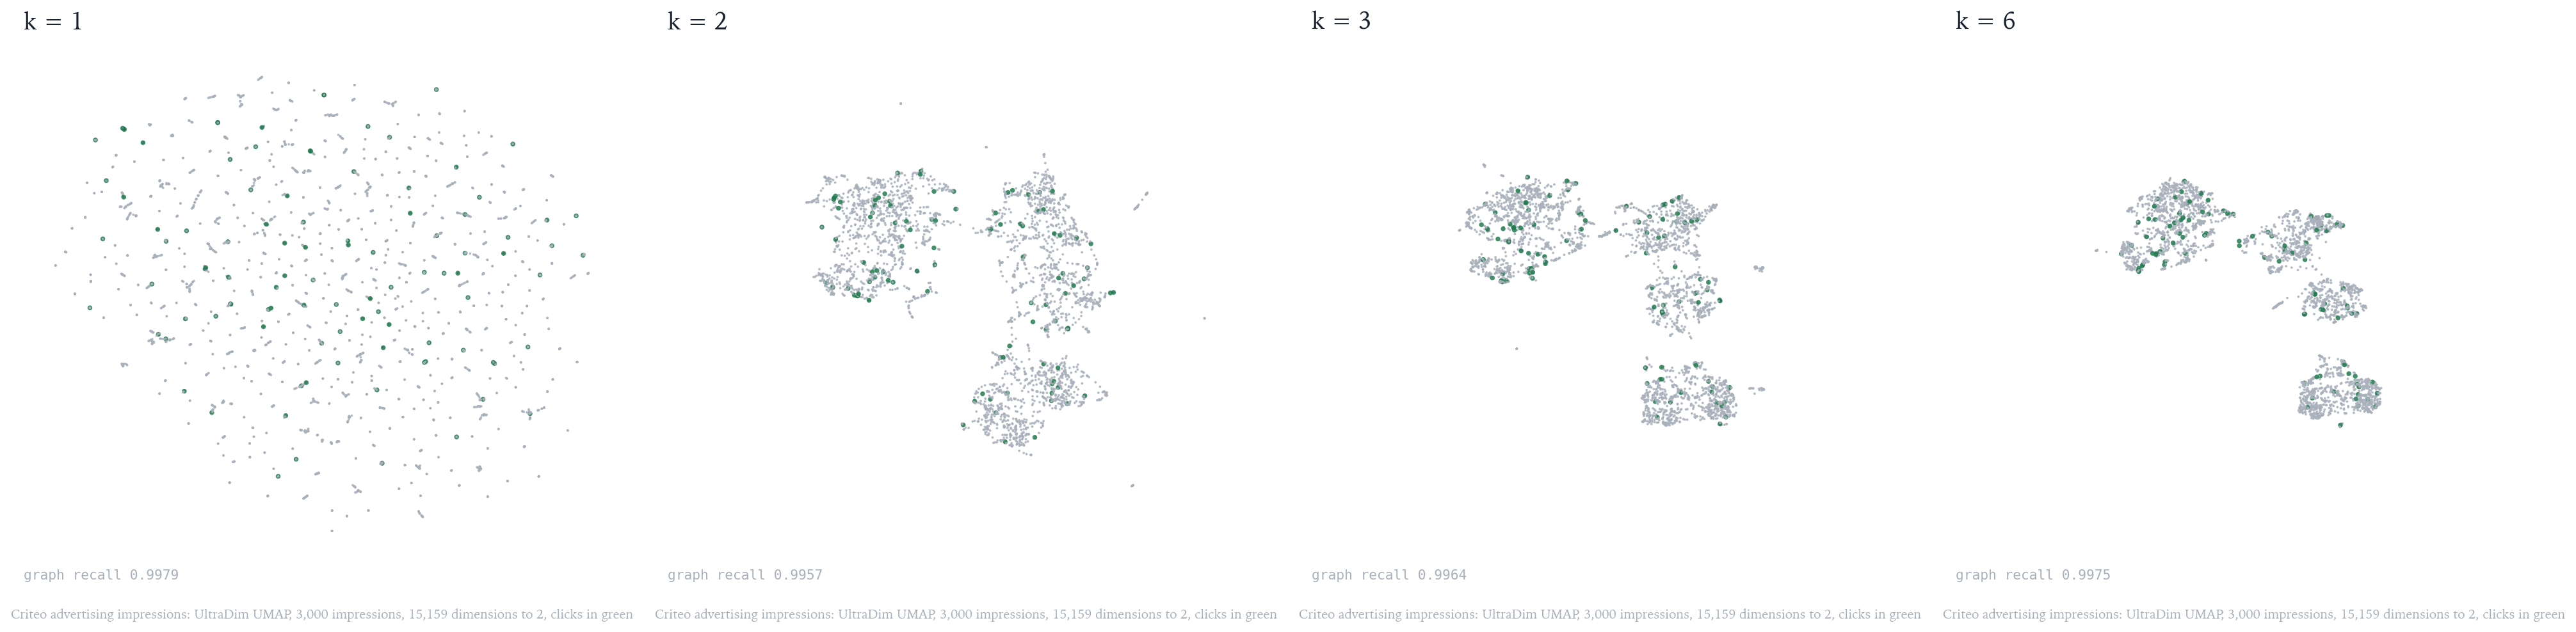

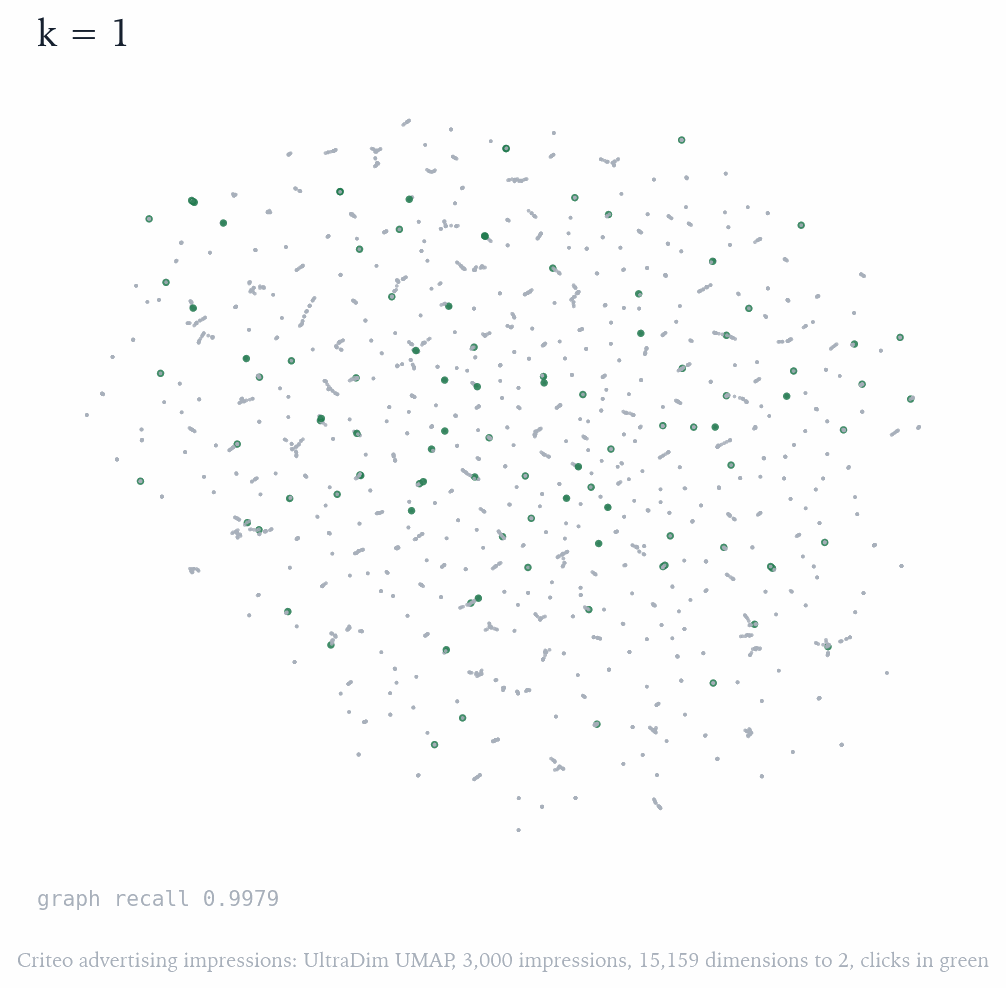

In [12]:
LIMS = None
for k in layouts:
    xy = np.array([layouts[k][i] for i in map_ids])
    box = (xy[:, 0].min(), xy[:, 0].max(), xy[:, 1].min(), xy[:, 1].max())
    LIMS = box if LIMS is None else (min(LIMS[0], box[0]), max(LIMS[1], box[1]),
                                     min(LIMS[2], box[2]), max(LIMS[3], box[3]))


def draw_map(ax, k, colour, sizes_):
    lay = layouts[k]
    xy = np.array([lay[i] for i in map_ids])
    ax.scatter(xy[:, 0], xy[:, 1], s=sizes_, c=colour, linewidths=0, alpha=0.85)
    pad = 0.06
    sx, sy = LIMS[1] - LIMS[0], LIMS[3] - LIMS[2]
    ax.set_xlim(LIMS[0] - pad * sx, LIMS[1] + pad * sx)
    ax.set_ylim(LIMS[2] - pad * sy, LIMS[3] + pad * sy)
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


def frame_path(k):
    return os.path.join(FIG_DIR, f"map_k{k:03d}.png")


clicked = labels[:ROWS_MAP] == 1
col_click = np.where(clicked, CLICK, GREY)
siz_click = np.where(clicked, 10.0, 2.6)
for k in range(1, K_MAX + 1):
    fig, ax = plt.subplots(figsize=(5.8, 5.8))
    draw_map(ax, k, col_click, siz_click)
    ax.set_title(f"k = {k}", fontsize=16)
    ax.text(0.0, -0.02, f"graph recall {graphs[k]['measured_recall_at_k']:.4f}",
            transform=ax.transAxes, fontsize=9, color=GREY, va="top", **MONO)
    fig.text(0.5, 0.01, "Criteo advertising impressions: UltraDim UMAP, "
             f"{ROWS_MAP:,} impressions, {WIDTH_MAP:,} dimensions to 2, clicks in green",
             ha="center", fontsize=8.5, color=GREY)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    fig.savefig(frame_path(k))
    plt.close(fig)

gif = os.path.join(FIG_DIR, "maps_over_k.gif")
frames = [Image.open(frame_path(k)).convert("P", palette=Image.ADAPTIVE)
          for k in range(1, K_MAX + 1)]
frames[0].save(gif, save_all=True, append_images=frames[1:],
               duration=[1400, 1400, 1050] + [700] * (K_MAX - 3), loop=0)
picks = [k for k in (1, 2, 3, K_MAX) if k <= K_MAX]
tiles = [Image.open(frame_path(k)).convert("RGB") for k in picks]
w, h = tiles[0].size
strip = Image.new("RGB", (w * len(tiles), h), "white")
for n, t in enumerate(tiles):
    strip.paste(t, (n * w, 0))
strip_path = os.path.join(FIG_DIR, "05_maps_over_k.png")
strip.save(strip_path)
print(f"{K_MAX} frames, a GIF and a strip written")
if IN_NOTEBOOK:
    display(NBImage(filename=strip_path))
    display(NBImage(filename=gif))

# Part three: what we found

## How many populations are there?

The map shows a handful of separated regions, which is a claim about the
data and can be checked without looking. Run the clustering at several
counts and score each against the null of no structure at all, corrected
for dimensionality. The count with the strongest score is the data's
answer; the map's blobs are ours.

   3 clusters: tightness against chance       10,704  (1 s)
   4 clusters: tightness against chance       11,007  (1 s)
   6 clusters: tightness against chance       11,625  (0 s)
   8 clusters: tightness against chance       11,902  (0 s)
  12 clusters: tightness against chance       12,717  (0 s)
  clustering: count chosen by the score = 12


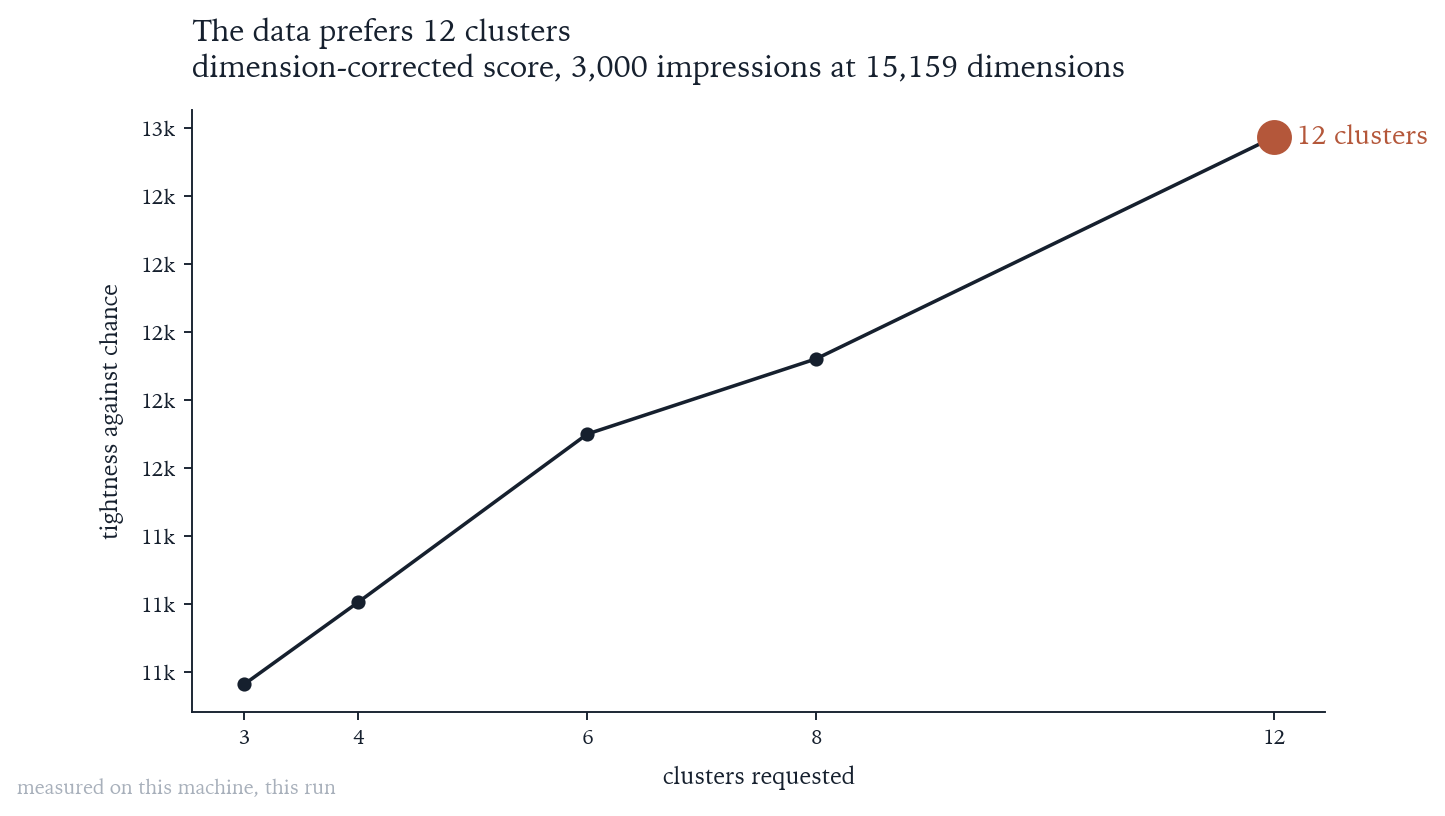

In [13]:
quality = []
for c in CLUSTER_COUNTS:
    t0 = time.time()
    km = rpc("ClusterUltradimV23", name=FAM_MAP, num_clusters=c, max_cycles=30)
    quality.append((c, km["mean_log10_p_real"], np.array(km["assignments"])))
    print(f"  {c:>2} clusters: tightness against chance {-km['mean_log10_p_real']:>12,.0f}  "
          f"({time.time() - t0:.0f} s)")
best_c, best_score, assign = min(quality, key=lambda r: r[1])
cost("clustering", "count chosen by the score", f"{best_c}")

fig, ax = plt.subplots(figsize=(8.6, 4.6))
cs = [q[0] for q in quality]
qs = [-q[1] for q in quality]
ax.plot(cs, qs, color=INK, linewidth=1.5, marker="o", markersize=5, zorder=3)
bi = cs.index(best_c)
ax.scatter([best_c], [qs[bi]], s=190, color=WARM, zorder=4)
ax.annotate(f"   {best_c} clusters", (best_c, qs[bi]), color=WARM, fontsize=11.5, va="center")
ax.set_xticks(cs)
ax.set_xlabel("clusters requested")
ax.set_ylabel("tightness against chance")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:,.0f}k"))
ax.set_title(f"The data prefers {best_c} clusters\ndimension-corrected score, "
             f"{ROWS_MAP:,} impressions at {WIDTH_MAP:,} dimensions")
finish(fig, "06_cluster_count.png", "measured on this machine, this run")

## Does the clustering agree with the map?

The map and the clustering are separate computations. One lays the
impressions out in two dimensions from a neighbour graph; the other
partitions them at their full width; neither is told what the other
found. Colouring the map by cluster shows whether they agree. Contiguous
colour means the structure is in the data rather than in either method.

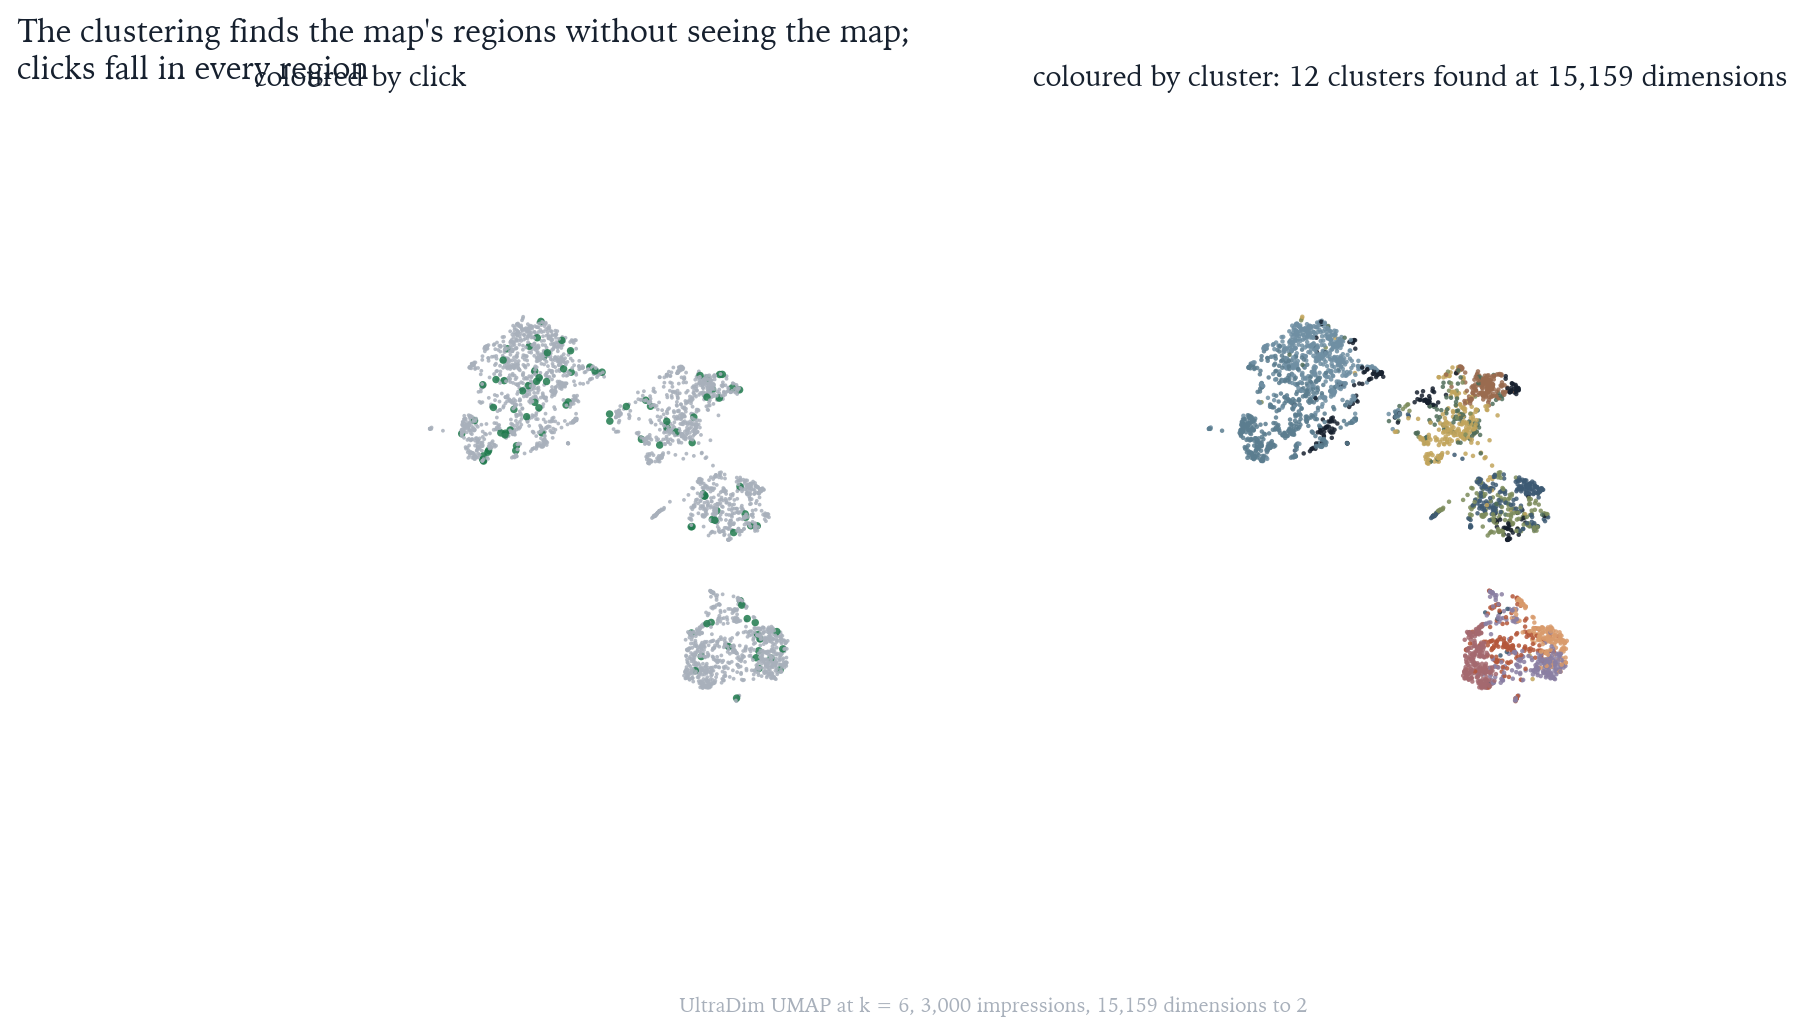

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 6.0), gridspec_kw={"wspace": 0.04})
draw_map(axes[0], K_MAX, col_click, siz_click)
axes[0].set_title("coloured by click", fontsize=12)
cluster_colour = [BAND[c % len(BAND)] for c in assign[:ROWS_MAP]]
draw_map(axes[1], K_MAX, cluster_colour, 3.6)
axes[1].set_title(f"coloured by cluster: {best_c} clusters found at {WIDTH_MAP:,} dimensions",
                  fontsize=12)
fig.suptitle("The clustering finds the map's regions without seeing the map;\n"
             "clicks fall in every region", x=0.005, ha="left", fontsize=13.5)
fig.text(0.5, 0.005, f"UltraDim UMAP at k = {K_MAX}, {ROWS_MAP:,} impressions, "
         f"{WIDTH_MAP:,} dimensions to 2", ha="center", fontsize=8.5, color=GREY)
path = os.path.join(FIG_DIR, "07_map_and_clusters.png")
fig.savefig(path, bbox_inches="tight")
plt.close(fig)
if IN_NOTEBOOK:
    display(NBImage(filename=path))

## What is each region made of?

A region is only interesting if something distinguishes it. For each
cluster, below, the feature values most over-represented inside it: lift
is the value's rate within the cluster divided by its rate outside.
Criteo's values are hashes, so none can be read as a name; a value
present in most of one region and almost nowhere else is a finding
regardless, and it is what an analyst would chase next.

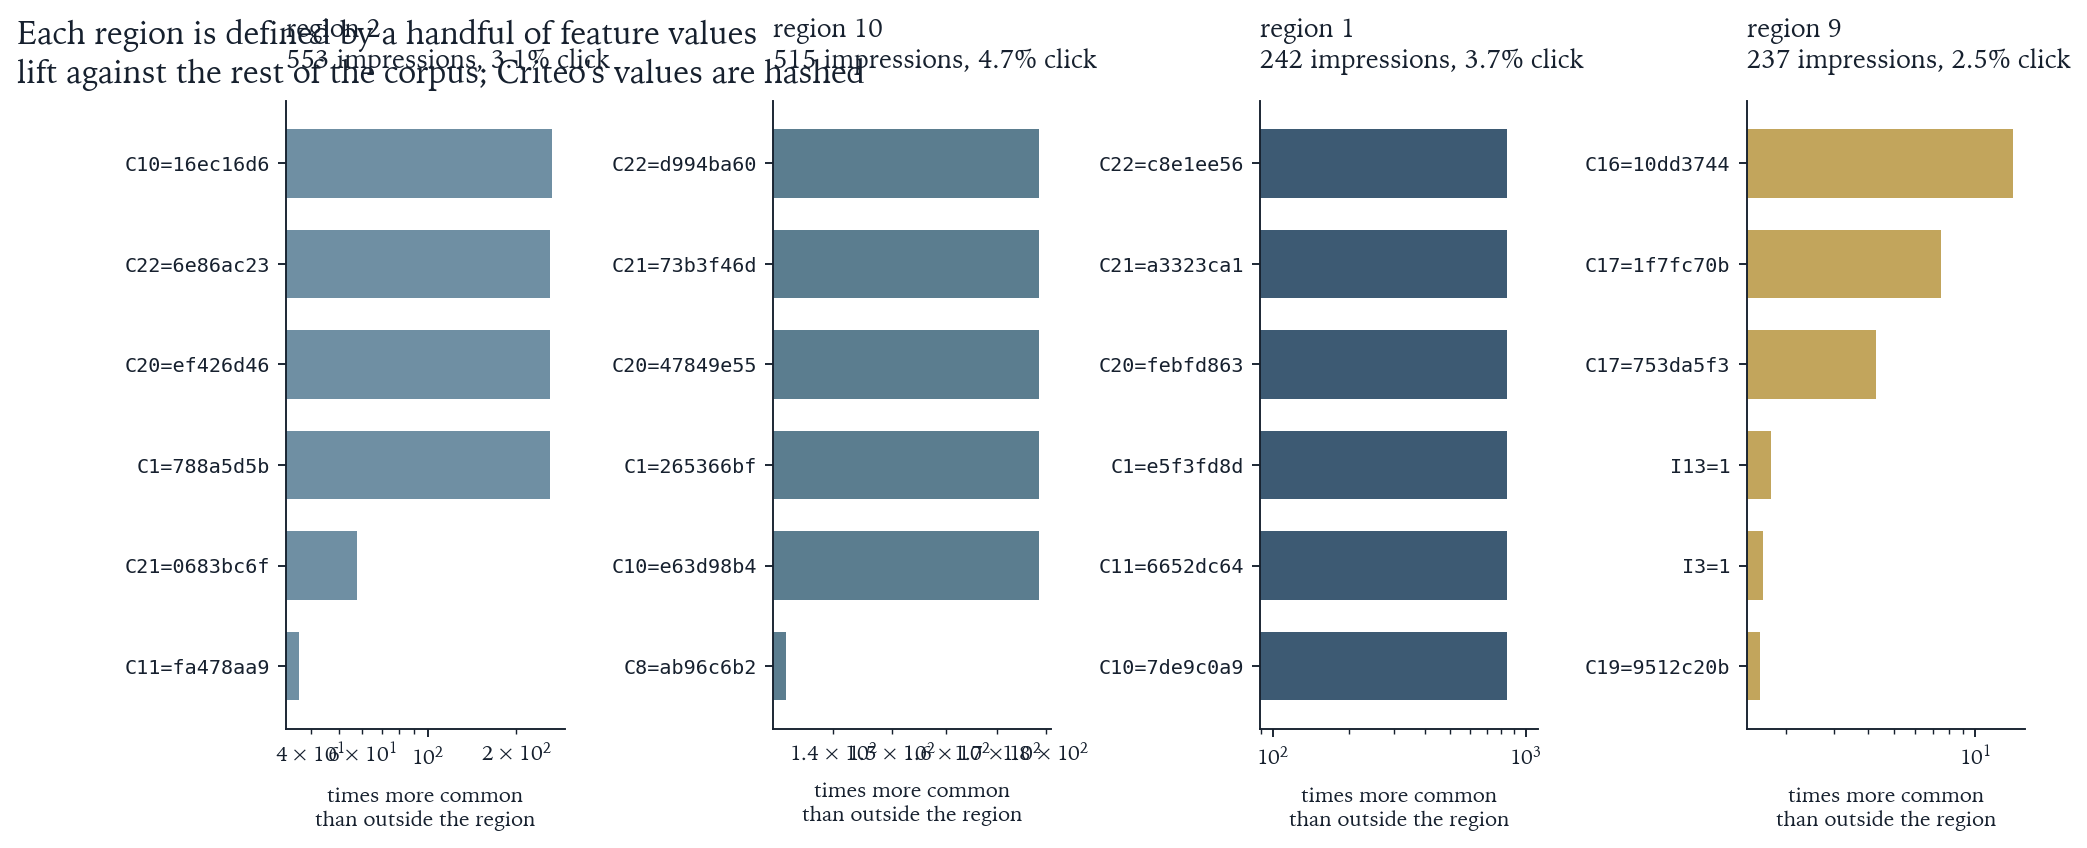

In [15]:
by_cluster = {c: [i for i in map_ids if assign[i] == c] for c in range(best_c)}
base = Counter(t for i in map_ids for t in feats_all[i])
lifts = {}
for c, idxs in by_cluster.items():
    if len(idxs) < 30:
        continue
    inside = Counter(t for i in idxs for t in feats_all[i])
    scored = []
    for t, n in inside.items():
        p_in = n / len(idxs)
        p_out = (base[t] - n) / max(1, ROWS_MAP - len(idxs))
        if p_in >= 0.30 and p_out < p_in:
            scored.append((p_in / max(p_out, 1e-6), p_in, t))
    lifts[c] = sorted(scored, reverse=True)[:6]

show = sorted(lifts, key=lambda c: -len(by_cluster[c]))[:4]
fig, axes = plt.subplots(1, len(show), figsize=(3.3 * len(show), 4.8),
                         gridspec_kw={"wspace": 0.75})
for ax, c in zip(np.atleast_1d(axes), show):
    items = lifts[c][::-1]
    ax.barh(range(len(items)), [min(x[0], 1000) for x in items],
            color=BAND[c % len(BAND)], height=0.68)
    ax.set_yticks(range(len(items)))
    ax.set_yticklabels([f"{t.split('=')[0]}={t.split('=')[1][:8]}" for _, _, t in items],
                       fontsize=8.5, **MONO)
    ax.set_xscale("log")
    ax.set_xlabel("times more common\nthan outside the region", fontsize=9)
    rate = labels[:ROWS_MAP][assign[:ROWS_MAP] == c].mean()
    ax.set_title(f"region {c}\n{len(by_cluster[c]):,} impressions, {rate:.1%} click",
                 fontsize=11)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.suptitle("Each region is defined by a handful of feature values\n"
             "lift against the rest of the corpus; Criteo's values are hashed",
             x=0.005, ha="left", fontsize=13.5)
path = os.path.join(FIG_DIR, "08_region_signatures.png")
fig.savefig(path, bbox_inches="tight")
plt.close(fig)
if IN_NOTEBOOK:
    display(NBImage(filename=path))

## Do the regions click differently?

The last part of the hypothesis. Each region's click rate with a 95%
interval, against the corpus rate. An interval clear of the line is an
audience that behaves differently from the average, found without the
label being used at any point.

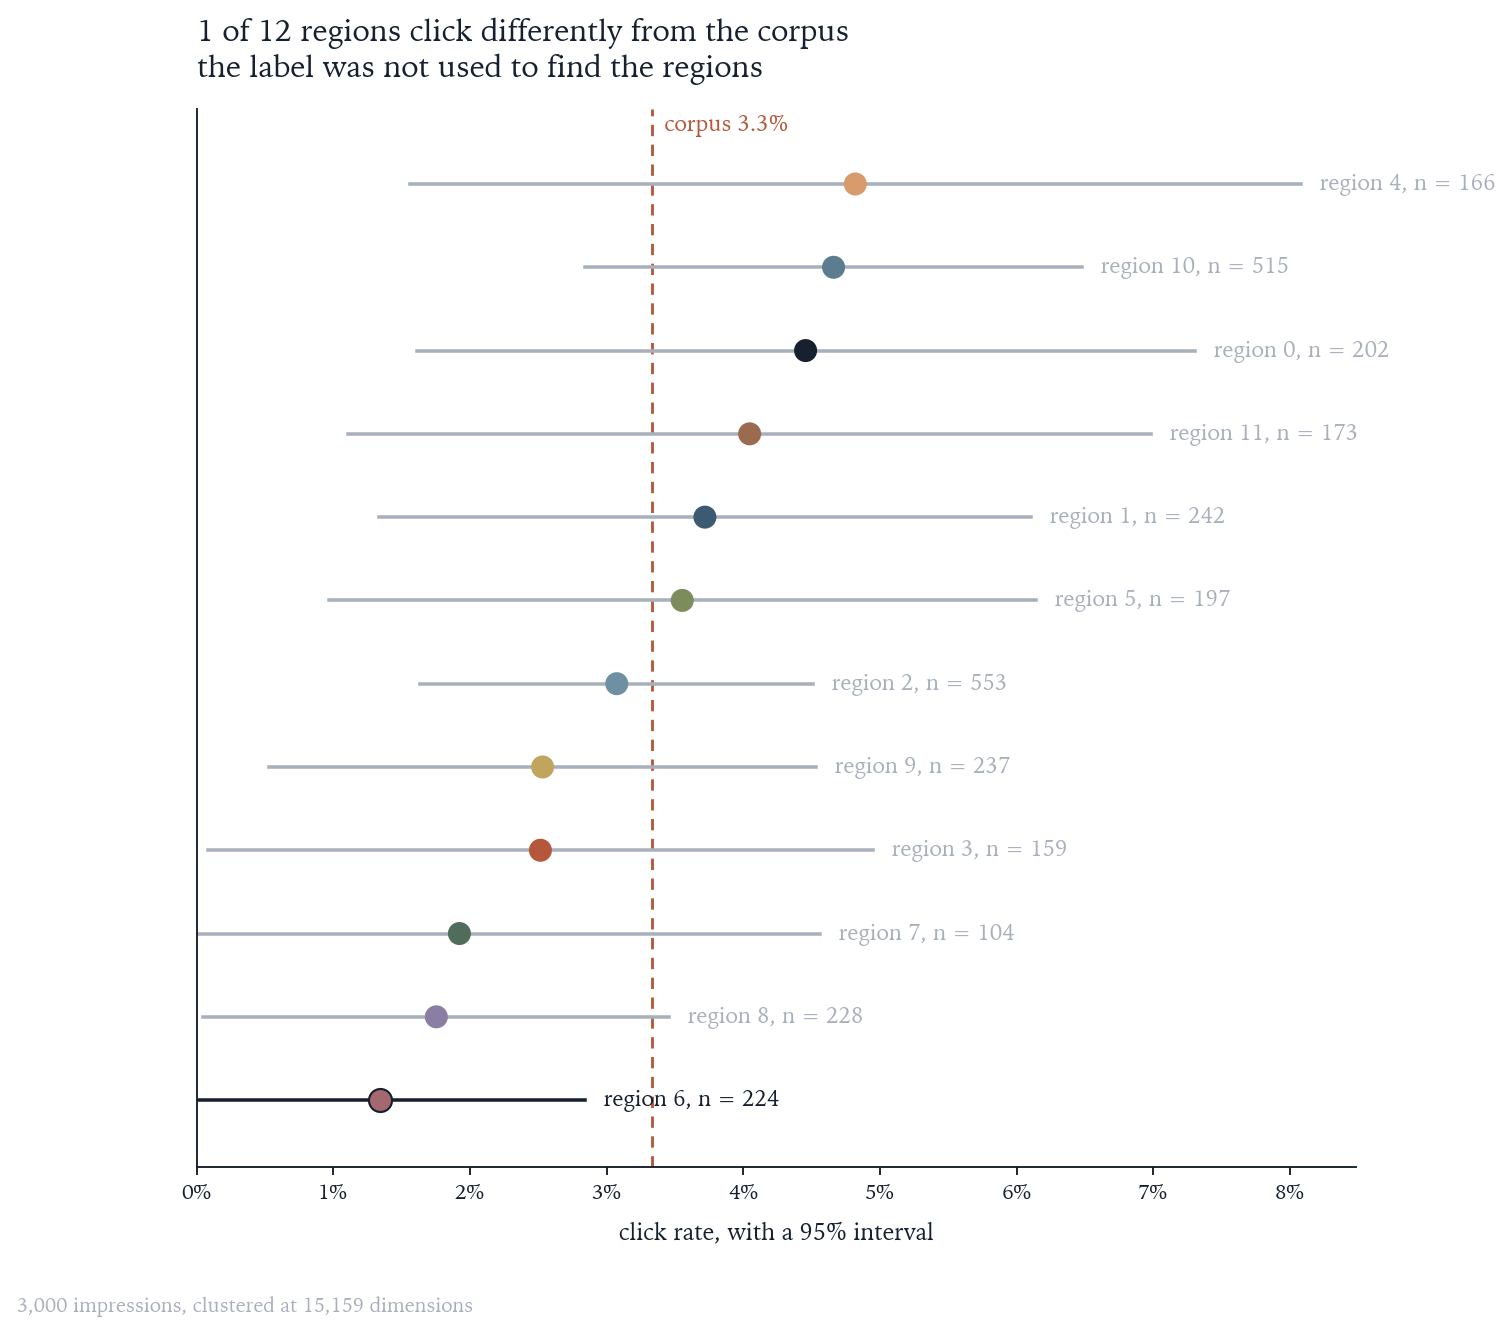

In [16]:
stats = []
for c in range(best_c):
    idx = assign[:ROWS_MAP] == c
    n = int(idx.sum())
    if n < 30:
        continue
    p = float(labels[:ROWS_MAP][idx].mean())
    stats.append((c, n, p, 1.96 * math.sqrt(max(p * (1 - p), 1e-9) / n)))
stats.sort(key=lambda r: r[2])
overall = labels[:ROWS_MAP].mean()
n_clear = sum(1 for _c, _n, p, ci in stats if (p - ci > overall) or (p + ci < overall))

fig, ax = plt.subplots(figsize=(8.8, 0.44 * len(stats) + 2.8))
for y, (c, n, p, ci) in enumerate(stats):
    clear = (p - ci > overall) or (p + ci < overall)
    ax.plot([max(p - ci, 0), p + ci], [y, y], color=INK if clear else GREY,
            linewidth=1.5, zorder=2)
    ax.scatter([p], [y], s=95, color=BAND[c % len(BAND)], zorder=3,
               edgecolor=INK if clear else "none", linewidth=0.9)
    ax.text(p + ci, y, f"   region {c}, n = {n:,}", va="center", fontsize=9.5,
            color=INK if clear else GREY)
ax.axvline(overall, color=WARM, linewidth=1.2, linestyle=(0, (4, 3)), zorder=1)
ax.text(overall, len(stats) - 0.35, f"  corpus {overall:.1%}", color=WARM, fontsize=9.5)
ax.set_yticks([])
ax.set_ylim(-0.8, len(stats) - 0.1)
ax.set_xlim(left=0)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("click rate, with a 95% interval")
ax.set_title(f"{n_clear} of {len(stats)} regions click differently from the corpus\n"
             "the label was not used to find the regions")
finish(fig, "09_click_by_region.png",
       f"{ROWS_MAP:,} impressions, clustered at {WIDTH_MAP:,} dimensions")

## The verdict on the hypothesis

In [17]:
recall_line = [v for s, m, v in COST if m.startswith("recall@10 at 4")]
top_lift = max((l[0][0] for l in lifts.values() if l), default=0.0)
print("HYPOTHESIS: impressions that share features are neighbours at full width.\n")
print(f"  the index returns the true neighbours   recall@10 = {recall_line[-1]} "
      f"against exact answers")
print(f"  the map shows separated regions          drawn at k = 1 … {K_MAX}")
print(f"  the clustering agrees, unprompted        {best_c} regions, tightness "
      f"{-best_score:,.0f} against chance")
print(f"  the regions have signatures              lift up to {top_lift:,.0f} times")
print(f"  the regions click differently            {n_clear} of {len(stats)} clear of "
      f"the corpus rate")

HYPOTHESIS: impressions that share features are neighbours at full width.

  the index returns the true neighbours   recall@10 = 0.9950 against exact answers
  the map shows separated regions          drawn at k = 1 … 6
  the clustering agrees, unprompted        12 regions, tightness 12,717 against chance
  the regions have signatures              lift up to 995,536 times
  the regions click differently            1 of 12 clear of the corpus rate


## What it cost

In [18]:
try:
    chip = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"],
                          capture_output=True, text=True).stdout.strip()
    mem = int(subprocess.run(["sysctl", "-n", "hw.memsize"],
                             capture_output=True, text=True).stdout) // 2**30
except Exception:
    chip, mem = platform.processor(), None
print(f"{chip or platform.machine()}, {mem} GB, {platform.system()} {platform.release()}, "
      f"UltraDim {ultradim.__version__}\n")
cost_df = pd.DataFrame(COST, columns=["step", "measure", "value"])
print(cost_df.to_string(index=False))
cost_df.to_csv(os.path.join(FIG_DIR, "cost_table.csv"), index=False)

Apple M3 Max, 128 GB, Darwin 23.4.0, UltraDim 0.4.0

                   step                   measure       value
      cast, whole shard    impressions per second      91,693
vocabulary, whole shard         distinct features   1,697,282
                  index         KB per impression        35.9
                  index                dimensions     113,799
                 search      recall@10 at 2 seeds      0.9820
                 search   p50 / p95 ms at 2 seeds 2.09 / 2.85
                 search      recall@10 at 4 seeds      0.9950
                 search   p50 / p95 ms at 4 seeds 2.65 / 3.37
                map k=1    graph recall / seconds  0.9979 / 0
                map k=2    graph recall / seconds  0.9957 / 0
                map k=3    graph recall / seconds  0.9964 / 0
                map k=4    graph recall / seconds  0.9968 / 0
                map k=5    graph recall / seconds  0.9970 / 0
                map k=6    graph recall / seconds  0.9975 / 0
             clus

## Running this on your own data

Replace one function. `features` turns one row of your table into a list
of strings, one per feature. Everything after it is unchanged: the
registry gives each distinct string a dimension, the encoder makes a unit
vector, and the index, the map and the clustering follow.

The control block is set for a first pass. The study sizes beside each
setting take about half an hour and produce these same figures with more
data behind them.